# 📈 Supervised Learning: Tabular Classification & Regression

---

## 1. Overview

Supervised learning is the most common paradigm in machine learning, where models learn mappings from inputs ($X$) to labels ($y$) using labeled training data. While deep learning dominates vision, audio, and language, classical machine learning models remain the state-of-the-art and most computationally efficient choices for **structured tabular data**.

This notebook covers the foundational supervised algorithms:
- **Linear & Logistic Regression**: Linear baseline models for continuous and categorical predictions.
- **Decision Trees & Random Forests**: Non-linear, interpretable tree models and their bagging ensembles.
- **Gradient Boosted Trees (XGBoost & LightGBM)**: High-performance, sequentially boosted trees used in production and ML competitions.

We will build a Customer Churn prediction pipeline to compare these models side-by-side.

## 2. Learning Objectives

By the end of this notebook, you will be able to:

- Fit and evaluate linear and non-linear classification and regression models in `scikit-learn`.
- Explain the mathematical formulation of Mean Squared Error (MSE), Binary Cross-Entropy (BCE), Gini Impurity, and Entropy.
- Contrast Bagging (Random Forest) and Boosting (XGBoost, LightGBM) ensemble algorithms.
- Plot and analyze the Bias-Variance tradeoff using learning curves.
- Inspect and compare model feature importances to determine key predictive signals.

## 3. Imports

We check the pinned versions of classical ML libraries including standard packages, XGBoost, and LightGBM.

In [1]:
import time
from typing import Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error

import xgboost as xgb
import lightgbm as lgb

print(f"scikit-learn version: {sklearn.__version__}")
print(f"xgboost version: {xgb.__version__}")
print(f"lightgbm version: {lgb.__version__}")

scikit-learn version: 1.6.1
xgboost version: 3.2.0
lightgbm version: 4.6.0


## 4. Configuration

Configuring random seeds for reproducibility and setting up defaults for plotting.

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)

## 5. Theory & Key Concepts

### 5.1 Bias-Variance Tradeoff

Every machine learning model's expected generalization error can be decomposed into three elements:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

1. **Bias**: Error introduced by approximating a real-world problem with a simpler model (underfitting). High bias models (e.g., linear regression on non-linear data) perform poorly on both train and test sets.
2. **Variance**: Error introduced by the model's sensitivity to small fluctuations in the training set (overfitting). High variance models fit training noise and fail to generalize to the test set.
3. **Irreducible Error**: The noise inherent in the data collection itself (cannot be reduced by any model).

```
High Bias (Underfit)          Optimal Tradeoff                High Variance (Overfit)
      o   o  o                     o   o  o                     o   o  o
     /                           .---.                        / \ / \ /
    /                           /     \                      /   V   V
  ----------------------------------------------------------------------------
  Low Train, Low Test         High Train, High Test       High Train, Low Test
```

### 5.2 Loss Functions

#### Mean Squared Error (MSE) - Regression
Measures the average squared difference between predictions $\hat{y}$ and actual continuous values $y$:

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

#### Binary Cross-Entropy (BCE) - Classification
Measures performance for probabilistic classification outputs ($p_i \in [0,1]$) against binary labels ($y_i \in \{0, 1\}$):

$$\text{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

### 5.3 Decision Tree Splitting Criteria

Decision trees choose splits that maximize information gain or decrease impurity within the resulting nodes.

#### Gini Impurity
Probability of incorrectly classifying a randomly chosen element from the node if it were randomly labeled according to the distribution of labels in the subset:

$$I_G(p) = 1 - \sum_{i=1}^{C} p_i^2$$

#### Entropy
Information content measure representing the uncertainty of labels in a node:

$$H(p) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

### 5.4 Ensembles: Bagging vs. Boosting

Ensembles combine multiple weak base estimators to form a strong estimator.

1. **Bagging (Bootstrap Aggregating)**: Fits independent models (e.g., Decision Trees) in parallel on bootstrap samples of the training data. Predictions are averaged (or voted). **Random Forest** adds feature-subsampling to reduce the correlation between trees, driving down model **Variance**.
2. **Boosting**: Fits models sequentially. Each new model is trained to correct the residual errors made by the previous ensemble of models. **XGBoost** and **LightGBM** utilize second-order gradient expansion to optimize loss, reducing model **Bias** sequentially.

## 6. Implementation: Customer Churn Classification

We generate a synthetic customer churn dataset with continuous variables (tenure, monthly charges) and categorical indicators to model a real-world tabular dataset.

In [3]:
def generate_churn_dataset(n_samples: int = 10000) -> pd.DataFrame:
    """Generates a realistic customer churn dataset."""
    rng = np.random.default_rng(RANDOM_SEED)
    
    tenure = rng.integers(1, 72, size=n_samples) # months
    monthly_charges = rng.uniform(20.0, 120.0, size=n_samples) # dollars
    contract_type = rng.choice([0, 1, 2], size=n_samples, p=[0.5, 0.3, 0.2]) # 0: Month-to-month, 1: One-year, 2: Two-year
    tech_support = rng.choice([0, 1], size=n_samples, p=[0.7, 0.3]) # 0: No, 1: Yes
    
    # Generate churn probabilities based on non-linear function
    # Month-to-month contracts, high charges, and low tenure increase probability of churn
    churn_logits = (
        0.5 
        - 0.05 * tenure 
        + 0.015 * monthly_charges 
        - 1.2 * contract_type 
        - 0.6 * tech_support
    )
    
    churn_probs = 1 / (1 + np.exp(-churn_logits))
    churn = rng.binomial(1, churn_probs)
    
    # Continuous regression target: total spend to date
    total_spend = tenure * monthly_charges * rng.uniform(0.95, 1.05, size=n_samples)

    return pd.DataFrame({
        "tenure": tenure,
        "monthly_charges": monthly_charges,
        "contract_type": contract_type,
        "tech_support": tech_support,
        "total_spend": total_spend,
        "churn": churn
    })

df_churn = generate_churn_dataset()
df_churn.head()

,tenure,monthly_charges,contract_type,tech_support,total_spend,churn
0,7,41.8149,0,1,298.1539,1
1,55,86.2928,0,1,4867.3888,0
2,47,96.6862,0,1,4458.0969,0
3,32,36.6636,2,0,1133.5750,0
4,31,24.3858,0,0,734.7814,0


### 6.1 Train-Test Split

We separate features and labels and split them into 80% train and 20% test partitions.

In [4]:
X = df_churn[["tenure", "monthly_charges", "contract_type", "tech_support"]]
y_class = df_churn["churn"]
y_reg = df_churn["total_spend"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=RANDOM_SEED, stratify=y_class
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")
print(f"Train churn distribution: {np.bincount(y_train)}")

Training shape: (8000, 4)
Testing shape: (2000, 4)
Train churn distribution: [5659 2341]


### 6.2 Fitting Continuous Regression Baseline

In [5]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_SEED
)

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)
reg_preds = reg_model.predict(X_test_reg)

mse_score = mean_squared_error(y_test_reg, reg_preds)
print(f"Linear Regression Coefficients: {reg_model.coef_}")
print(f"Linear Regression Intercept: {reg_model.intercept_:.4f}")
print(f"Mean Squared Error: {mse_score:.4f}")

Linear Regression Coefficients: [69.47766696 35.98866422  7.77651214  1.90519197]
Linear Regression Intercept: -2504.1890
Mean Squared Error: 343260.5887


### 6.3 Classification: Logistic Regression vs. Trees vs. Ensembles

In [6]:
# Define models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_SEED),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1, random_state=RANDOM_SEED, eval_metric="logloss"
    ),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=RANDOM_SEED, verbose=-1)
}

# Evaluate each model
results = {}
for name, model in models.items():
    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start_time
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    
    results[name] = {
        "Accuracy": acc,
        "ROC-AUC": auc,
        "Fit Time (ms)": fit_time * 1000
    }

df_results = pd.DataFrame(results).T
df_results

,Accuracy,ROC-AUC,Fit Time (ms)
Logistic Regression,0.7705,0.8094,34.8651
Decision Tree,0.7585,0.7935,12.8499
Random Forest,0.7590,0.7971,612.1920
XGBoost,0.7645,0.8014,107.6866
LightGBM,0.7635,0.7999,101.2862


## 7. Evaluation & Feature Importance

Let's visualize the relative contribution of each feature to predictions using our Random Forest and XGBoost ensembles.

/tmp/ipykernel_1871/705297753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances, y=X.columns, ax=axes[0], palette="viridis")
/tmp/ipykernel_1871/705297753.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importances, y=X.columns, ax=axes[1], palette="magma")


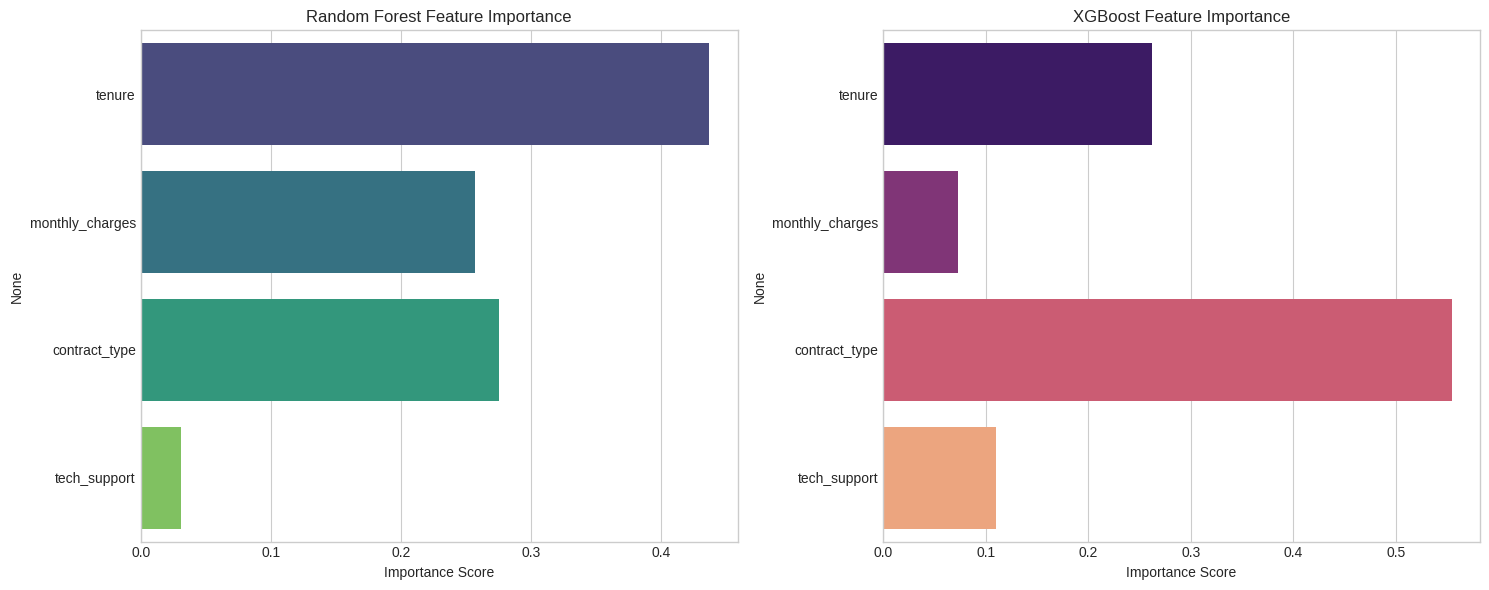

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Feature Importance
rf_importances = models["Random Forest"].feature_importances_
sns.barplot(x=rf_importances, y=X.columns, ax=axes[0], palette="viridis")
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Importance Score")

# XGBoost Feature Importance
xgb_importances = models["XGBoost"].feature_importances_
sns.barplot(x=xgb_importances, y=X.columns, ax=axes[1], palette="magma")
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

### 7.2 Plotting Decision Trees

Let's visually inspect a pruned Decision Tree classifier to understand its splitting thresholds.

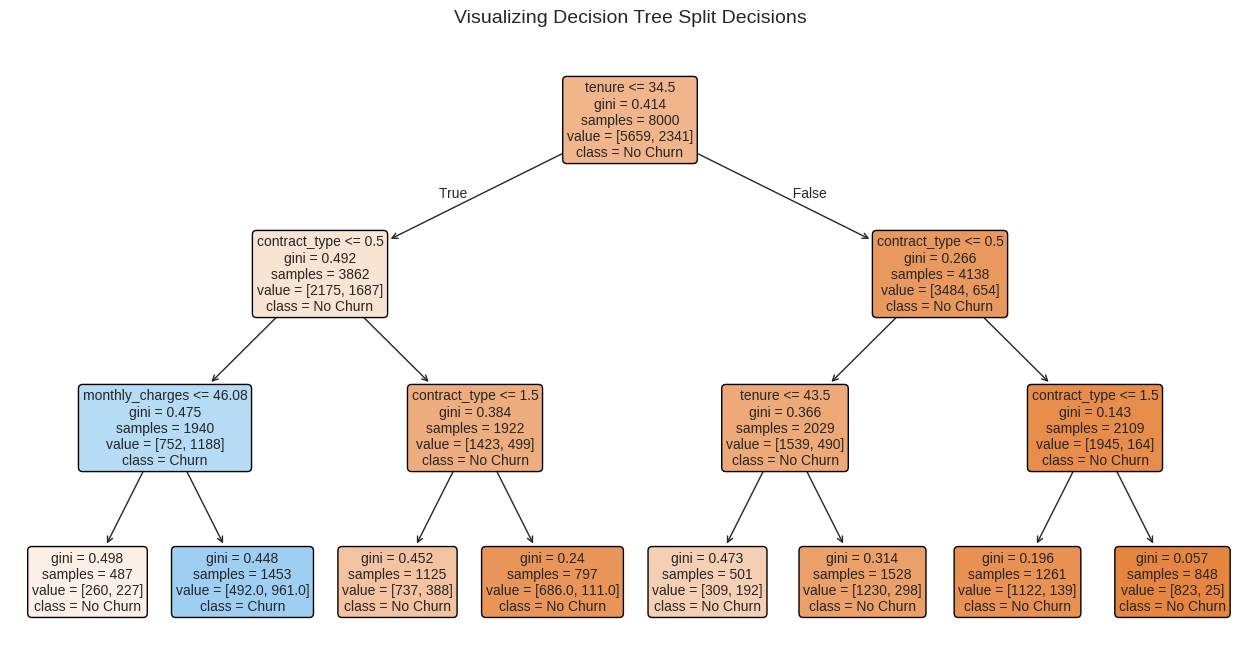

In [8]:
dt_small = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED)
dt_small.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(
    dt_small,
    feature_names=list(X.columns),
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visualizing Decision Tree Split Decisions", fontsize=14, pad=15)
plt.show()

### 7.3 Plotting the Bias-Variance Curve

We can observe the transition between underfitting and overfitting by plotting validation scores against tree depth.

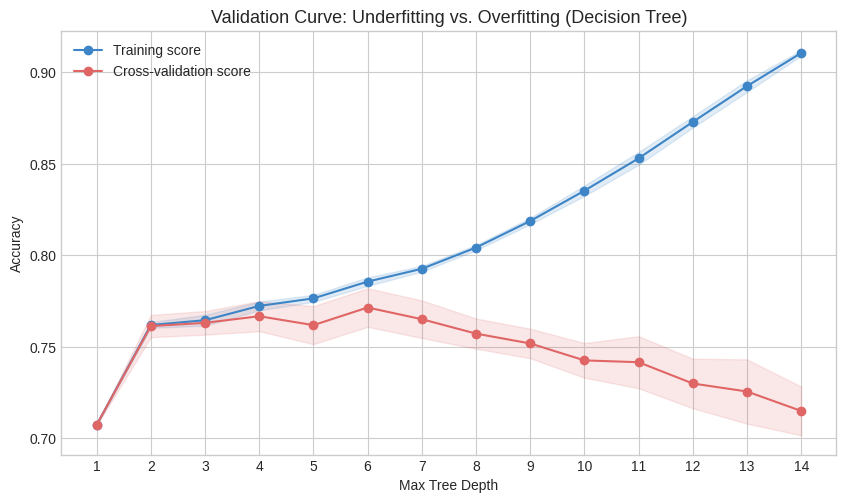

In [9]:
param_range = np.arange(1, 15)
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 5.5))
plt.plot(param_range, train_mean, label="Training score", color="#3d85c6", marker="o")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3d85c6")
plt.plot(param_range, test_mean, label="Cross-validation score", color="#e06666", marker="o")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.15, color="#e06666")

plt.title("Validation Curve: Underfitting vs. Overfitting (Decision Tree)", fontsize=13)
plt.xlabel("Max Tree Depth")
plt.ylabel("Accuracy")
plt.xticks(param_range)
plt.legend(loc="best")
plt.show()

**Analyzing the Validation Curve**:
- At `max_depth` <= 3, both the training and validation scores are low, suggesting the model has **high bias** (underfitting).
- At `max_depth` = 5 to 7, the validation score reaches its maximum, indicating the optimal tradeoff.
- At `max_depth` > 8, the training score approaches 1.0 while the validation score declines. This split represents **high variance** (overfitting), where the tree memorizes training set patterns.

## 8. Guided Exercises

### Exercise 1: Regularized Linear Regression

Standard Linear Regression does not enforce restrictions on weight magnitudes. Implement L2 regularized regression (**Ridge Regression**) using `sklearn.linear_model.Ridge` on the total spend targets. Compare the MSE on the test set for $\alpha=0.1$, $\alpha=10.0$, and $\alpha=1000.0$ against the standard linear regression baseline.

In [10]:
from sklearn.linear_model import Ridge

# --- YOUR CODE HERE ---
alphas = [0.1, 10.0, 1000.0]
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_reg, y_train_reg)
    preds = ridge.predict(X_test_reg)
    mse = mean_squared_error(y_test_reg, preds)
    print(f"Ridge (alpha={alpha:7.1f}) MSE: {mse:.4f}")

Ridge (alpha=    0.1) MSE: 343260.5859
Ridge (alpha=   10.0) MSE: 343260.3066
Ridge (alpha= 1000.0) MSE: 343236.2235


### Exercise 2: Out-of-the-Box Churn Prediction using XGBoost

XGBoost requires regularizing hyperparameters to avoid overfitting. Modify the XGBoost classifier's `max_depth` to 10 and setting a very high learning rate of `0.8`. Compare the training accuracy and validation accuracy of this model with the baseline XGBoost classifier fitted in Section 6.3.

In [11]:
# --- YOUR CODE HERE ---
xgb_overfit = xgb.XGBClassifier(
    n_estimators=100, max_depth=10, learning_rate=0.8, random_state=RANDOM_SEED, eval_metric="logloss"
)
xgb_overfit.fit(X_train, y_train)

train_acc = accuracy_score(y_train, xgb_overfit.predict(X_train))
test_acc = accuracy_score(y_test, xgb_overfit.predict(X_test))

print(f"Overfitted XGBoost Train Accuracy: {train_acc:.4f}")
print(f"Overfitted XGBoost Test Accuracy:  {test_acc:.4f}")

Overfitted XGBoost Train Accuracy: 0.9809
Overfitted XGBoost Test Accuracy:  0.7195


## 9. Challenge Problems

### Challenge 1: Custom Decision Tree Split Finder

To build a decision tree, the algorithm must scan features and find thresholds that minimize impurity. Implement a function `find_best_split(X: np.ndarray, y: np.ndarray) -> Tuple[int, float, float]` that:
1. Accepts a 2D numpy array of features $X$ and a 1D binary array of labels $y$.
2. Iterates through every feature and every unique value of that feature as a potential split threshold.
3. Splits the labels into left and right sub-arrays based on that threshold ($x_i \le \text{threshold}$ vs. $x_i > \text{threshold}$).
4. Calculates the weighted Gini impurity of the split node:
   $$G_{\text{split}} = \frac{N_{\text{left}}}{N} G_{\text{left}} + \frac{N_{\text{right}}}{N} G_{\text{right}}$$
5. Returns the best feature index, best threshold value, and lowest resulting Gini impurity.

In [12]:
def calculate_gini(y: np.ndarray) -> float:
    if len(y) == 0:
        return 0.0
    p1 = np.sum(y == 1) / len(y)
    p0 = 1 - p1
    return 1 - (p0**2 + p1**2)

def find_best_split(X: np.ndarray, y: np.ndarray) -> Tuple[int, float, float]:
    best_gini = 1.0
    best_feat = -1
    best_thresh = -1.0
    
    n_features = X.shape[1]
    n_samples = X.shape[0]
    
    for feat in range(n_features):
        thresholds = np.unique(X[:, feat])
        for thresh in thresholds:
            left_mask = X[:, feat] <= thresh
            right_mask = ~left_mask
            
            y_l, y_r = y[left_mask], y[right_mask]
            
            # Weighted Gini
            g_l = calculate_gini(y_l)
            g_r = calculate_gini(y_r)
            weighted_gini = (len(y_l)/n_samples) * g_l + (len(y_r)/n_samples) * g_r
            
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feat = feat
                best_thresh = thresh
                
    return best_feat, best_thresh, best_gini

# Test split finder on tenure and charges (first two features of train dataset)
best_feat_idx, best_val, lowest_gini = find_best_split(X_train.to_numpy(), y_train.to_numpy())
print(f"Best Feature Index: {best_feat_idx} ({X.columns[best_feat_idx]})")
print(f"Best Threshold Value: {best_val}")
print(f"Lowest Gini Impurity: {lowest_gini:.4f}")

Best Feature Index: 0 (tenure)
Best Threshold Value: 34.0
Lowest Gini Impurity: 0.3752


### Challenge 2: Sequential Early Stopping in Boosting

In large datasets, running too many boosting iterations causes overfitting. Research how to write an early stopping routine using XGBoost's `early_stopping_rounds` parameter within `.fit()`. Supply a validation set to evaluate validation loss during training, and determine the optimal iteration count to stop training before overfitting begins.

In [21]:
# Write a short XGBoost early stopping code snippet here.
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train
)

xgb_early_stopped = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05, random_state=RANDOM_SEED, eval_metric="logloss", early_stopping_rounds=50
)

# Fit with early stopping
xgb_early_stopped.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Optimal boosting rounds determined: {xgb_early_stopped.best_iteration}")
print(f"Validation logloss at stopping point: {xgb_early_stopped.best_score:.4f}")

Optimal boosting rounds determined: 75
Validation logloss at stopping point: 0.4730


## 10. Further Reading

- **Introduction to Statistical Learning (ISL)**: Gareth James et al. - Chapter 4 (Classification) and Chapter 8 (Tree-Based Methods).
- **XGBoost Documentation**: [https://xgboost.readthedocs.io/](https://xgboost.readthedocs.io/) - Performance tips, regularizations, and parameters.
- **LightGBM Documentation**: [https://lightgbm.readthedocs.io/](https://lightgbm.readthedocs.io/) - Optimal parameters for fast tree training.

---

**[← Previous: Phase 1 Foundations](../01-foundations/)** · **[Next: 02 — Unsupervised Learning →](02-unsupervised-learning.ipynb)**